In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_comparison(original, transformed, title_orig='Original', title_trans='Transformed'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title(title_orig, fontsize=13)
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB))
    axes[1].set_title(title_trans, fontsize=13)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

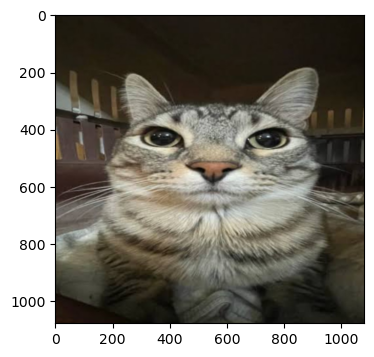

In [47]:
IMAGE = 'cat.jpg'  

image = cv2.imread(IMAGE)

gray_mean = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).mean()
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

### Part 1: Power Law Transformation (Gamma Correction)

- **γ < 1** — brightens dark images  
- **γ > 1** — increases contrast in washed-out / bright images  
- **c = 1** — standard gamma correction (no extra scaling)

Define `gamma_correction` function

In [48]:
def gamma_correction(I_in, c, gamma):
    I_norm = I_in.astype('float32') / 255

    I_transformed = c * (I_norm ** gamma)

    I_out = np.clip(I_transformed, 0, 1) * 255
    I_out = I_out.astype('uint8')

    return I_out

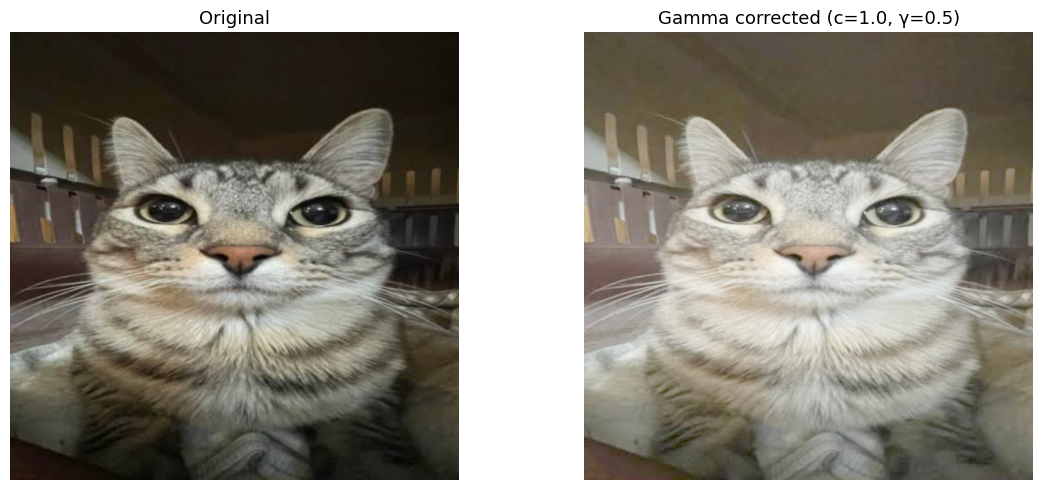

Gamma used: 0.5
Reason: The image appeared dark, so γ < 1 was used to brighten shadow regions.


In [49]:
c     = 1.0   
gamma = 0.5 

corrected = gamma_correction(image, c=c, gamma=gamma)

show_comparison(image, corrected,
                title_orig='Original',
                title_trans=f'Gamma corrected (c={c}, γ={gamma})')

print(f'Gamma used: {gamma}')
if gamma < 1:
    print('Reason: The image appeared dark, so γ < 1 was used to brighten shadow regions.')
else:
    print('Reason: The image appeared washed out / bright, so γ > 1 was used to increase contrast.')

In [50]:
I_norm = image.astype('float32') / 255

I_norm_uint8 = (I_norm * 255).astype('uint8')
cv2.imwrite('newcat.png', I_norm_uint8)

print('Problem : cv2.imwrite expects uint8 [0-255]. Float values [0.0-1.0] get truncated to 0 -> black image.')
print('Solution: multiply by 255 and cast to uint8 before saving.')

Problem : cv2.imwrite expects uint8 [0-255]. Float values [0.0-1.0] get truncated to 0 -> black image.
Solution: multiply by 255 and cast to uint8 before saving.


### Part 2: Contrast Stretching


Define `contrast_stretching` function

In [27]:
def contrast_stretching(i_in, s_max, s_min):
    img   = i_in.astype('float32')
    r_min = float(img.min())
    r_max = float(img.max())

    s_out = ((s_max - s_min) / (r_max - r_min)) * (img - r_min) + s_min
    s_out = np.clip(s_out, min(s_min, s_max), max(s_min, s_max))
    s_out = s_out.astype('uint8')
    return s_out

Task 2.1 — Non-normalized image (s_min=0, s_max=255)

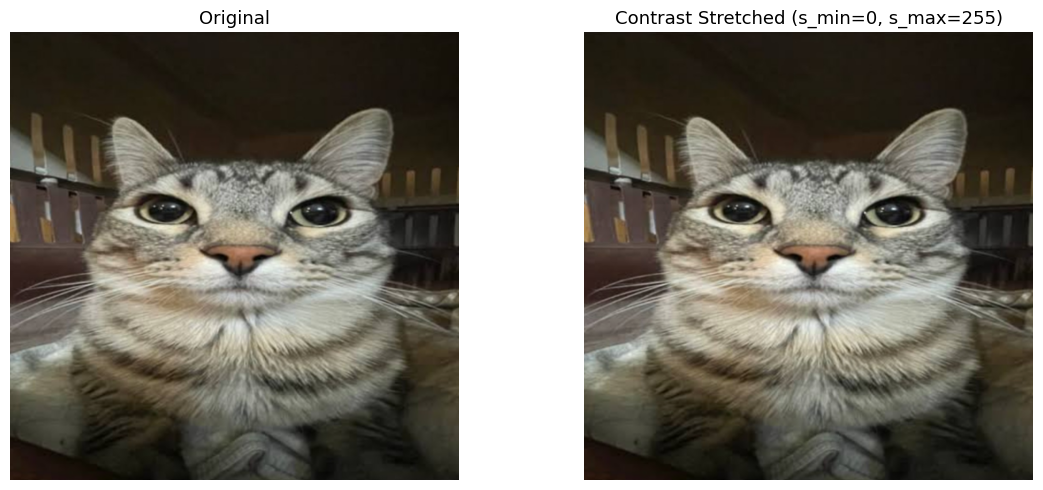

In [28]:
stretched_full = contrast_stretching(image, s_max=255, s_min=0)

show_comparison(image, stretched_full,
                title_orig='Original',
                title_trans='Contrast Stretched (s_min=0, s_max=255)')

Task 2.2 — Normalized image (s_min=0, s_max=1)

Task 2.3 — Does normalizing affect the output?

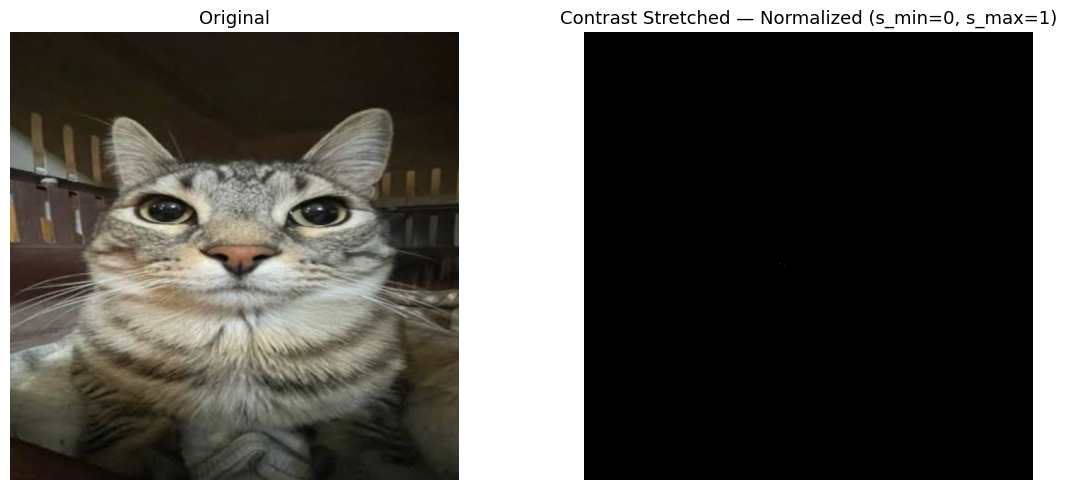

In [29]:
I_norm_float   = image.astype('float32') / 255
stretched_norm = contrast_stretching(I_norm_float, s_max=1.0, s_min=0.0)

stretched_norm_display = (stretched_norm * 255).astype('uint8')

show_comparison(image, stretched_norm_display,
                title_orig='Original',
                title_trans='Contrast Stretched — Normalized (s_min=0, s_max=1)')

**Answer:** No visual difference. Contrast stretching is a linear, scale-invariant operation — it maps the input range proportionally to the output range. Whether values are in [0, 255] or [0, 1], the scaling ratio stays identical, so the final result looks the same after rescaling back for display.

Task 2.4 — Various (s_min, s_max) combinations

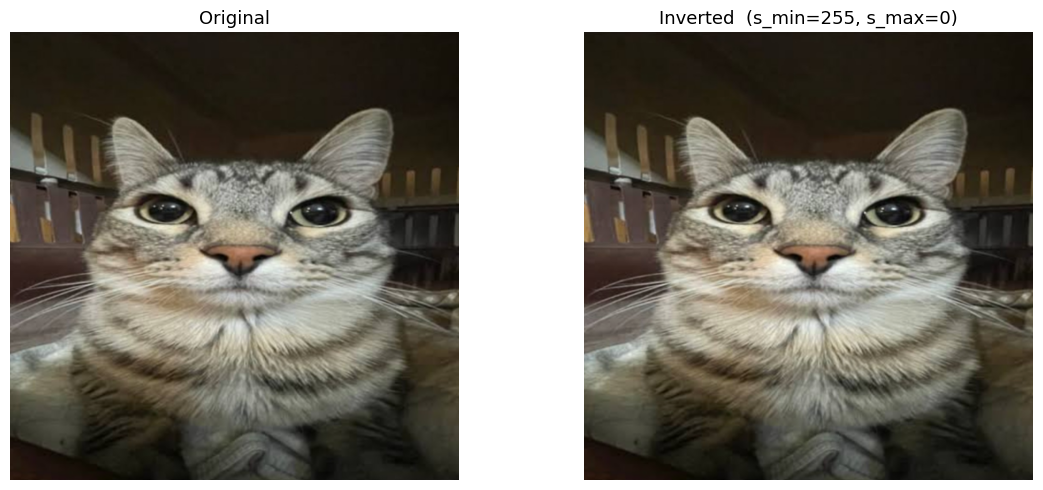

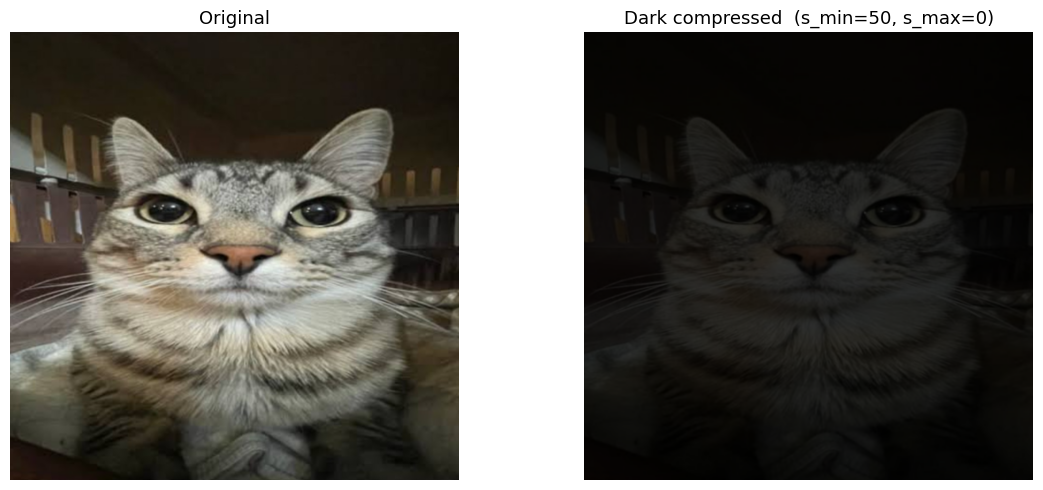

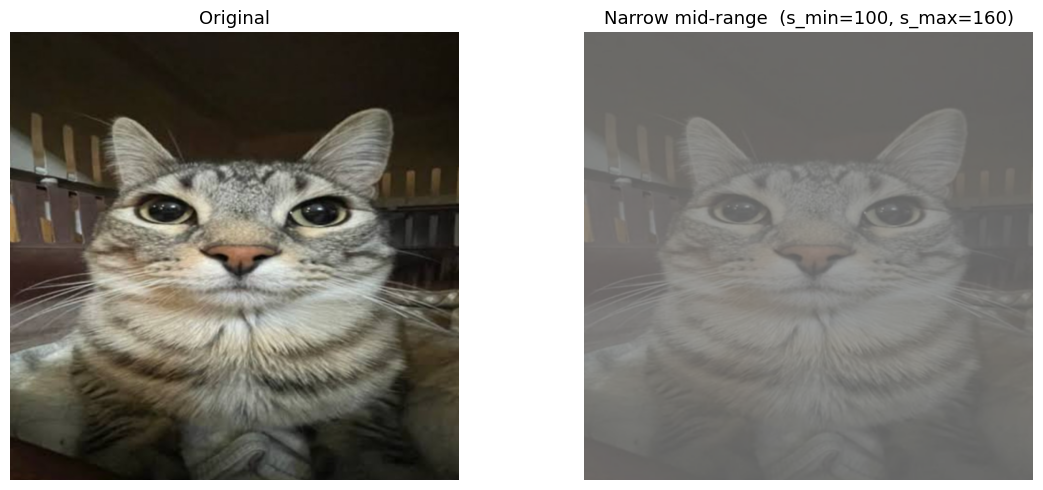

  s_min=255, s_max=0   -> image is fully inverted (like a photographic negative)
  s_min=0,   s_max=50  -> output compressed to dark range [0,50] — very dark image
  s_min=100, s_max=160 -> output restricted to mid-range — low contrast, washed-out look


In [55]:
combos = [
    (255, 0,   'Inverted  (s_min=255, s_max=0)'),
    (50,  0,   'Dark compressed  (s_min=50, s_max=0)'),
    (160, 100, 'Narrow mid-range  (s_min=100, s_max=160)'),
]

for s_max, s_min, label in combos:
    out = contrast_stretching(image, s_max=s_max, s_min=s_min)
    show_comparison(image, out, title_orig='Original', title_trans=label)

print('  s_min=255, s_max=0   -> image is fully inverted (like a photographic negative)')
print('  s_min=50,   s_max=0  -> output compressed to dark range [0,50] — very dark image')
print('  s_min=100, s_max=160 -> output restricted to mid-range — low contrast, washed-out look')

Gamma correction applies $T(r) = c \cdot r^{\gamma}$ to each normalized pixel intensity. The parameter **γ** controls the shape of the tone mapping curve:

- **γ < 1** expands dark regions and compresses bright ones — ideal for underexposed or dark images. Common values: 0.4–0.7.
- **γ > 1** compresses dark regions and expands bright ones — useful for reducing haze or increasing contrast in overexposed images. Common values: 1.5–3.0.
- **γ = 1** leaves the image unchanged.

The gamma value is chosen based on visual inspection: dark image → γ < 1; bright/washed-out image → γ > 1. Gamma correction is widely used in photography, medical imaging (X-ray, MRI), and display calibration.

**Important note on saving:** After normalizing an image to float32 [0, 1], it must be multiplied by 255 and cast to uint8 before saving with `cv2.imwrite` — otherwise all values are truncated to 0, producing a completely black file.

Contrast stretching is a linear point operation that remaps the intensity range $[r_{min}, r_{max}]$ found in an image to a desired output range $[s_{min}, s_{max}]$. Setting $s_{min}=0$ and $s_{max}=255$ fully utilizes the 8-bit dynamic range, making details much more visible in low-contrast images caused by poor lighting.

Unlike gamma correction, contrast stretching is **linear** and does not selectively enhance specific tonal regions. Non-standard parameter choices — such as an inverted or very narrow output range — produce negative-looking, dark, or flat results. Normalizing the image before contrast stretching produces no visible difference in the final output, as the linear ratio is preserved across any consistent scaling.